# Ансамбли моделей

Сравним одиночное дерево, случайный лес и градиентный бустинг через стратифицированную кросс-валидацию. После сравнения исследуем важность признаков случайного леса.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")

## Модели и кросс-валидация

In [2]:
features, target = load_breast_cancer(return_X_y=True, as_frame=True)
validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=250, min_samples_leaf=2, n_jobs=1, random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=150, learning_rate=0.08, random_state=42),
}

In [3]:
fold_rows = []
for name, model in models.items():
    scores = cross_validate(
        model,
        features,
        target,
        cv=validation,
        scoring={"f1": "f1", "roc_auc": "roc_auc"},
        n_jobs=1,
    )
    for fold, (f1, roc_auc) in enumerate(zip(scores["test_f1"], scores["test_roc_auc"]), start=1):
        fold_rows.append({"model": name, "fold": fold, "f1": f1, "roc_auc": roc_auc})

fold_results = pd.DataFrame(fold_rows)
summary = fold_results.groupby("model")[["f1", "roc_auc"]].agg(["mean", "std"])
summary

f1             roc_auc          
                       mean       std      mean       std
model                                                    
Decision Tree      0.936434  0.013080  0.943656  0.012492
Gradient Boosting  0.967080  0.021014  0.992179  0.006969
Random Forest      0.962599  0.014400  0.990369  0.008712

## Сравнение качества

/var/folders/pk/9xprbn3n0l976phskwjq30ww0000gn/T/ipykernel_29992/396002477.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_data, x="model", y="score", hue="metric", dodge=True, color="black", alpha=0.5, legend=False)


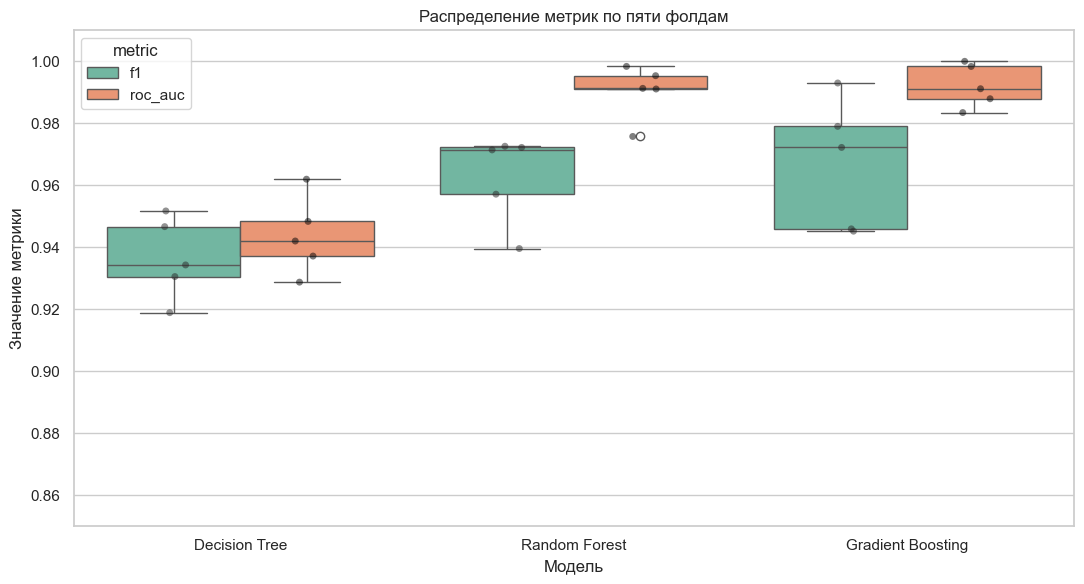

In [4]:
plot_data = fold_results.melt(
    id_vars=["model", "fold"],
    value_vars=["f1", "roc_auc"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(11, 6))
sns.boxplot(data=plot_data, x="model", y="score", hue="metric", palette="Set2")
sns.stripplot(data=plot_data, x="model", y="score", hue="metric", dodge=True, color="black", alpha=0.5, legend=False)
plt.title("Распределение метрик по пяти фолдам")
plt.xlabel("Модель")
plt.ylabel("Значение метрики")
plt.ylim(0.85, 1.01)
plt.tight_layout()
plt.show()

## Важность признаков Random Forest

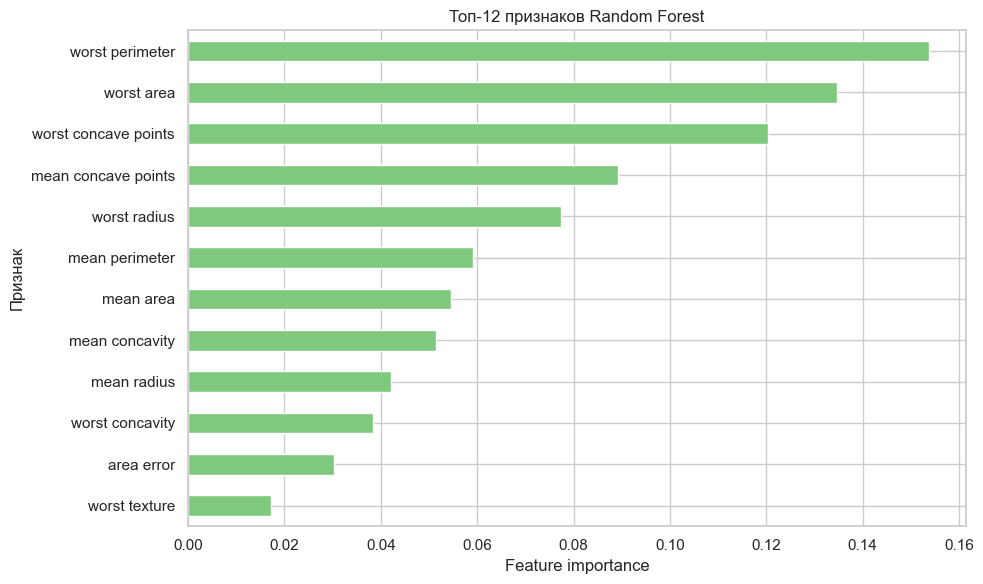

In [5]:
forest = models["Random Forest"]
forest.fit(features, target)
importance = pd.Series(forest.feature_importances_, index=features.columns).nlargest(12).sort_values()

importance.plot.barh(figsize=(10, 6), color="#7fc97f")
plt.title("Топ-12 признаков Random Forest")
plt.xlabel("Feature importance")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

## Вывод

Одиночное дерево проще объяснить, но ансамбли обычно дают более устойчивое качество. Разброс метрик между фолдами показывает стабильность оценки, а feature importance помогает понять, какие признаки чаще используются случайным лесом.